In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [31]:
def destripe_fft_simple(img_gray, stripe_width=1):
    """
    Remove stripe noise using FFT - SIMPLEST METHOD
    img_gray: grayscale image 
    stripe_width: width of stripe (usually 1-3 pixels)
    """
    h, w = img_gray.shape
    
    # FFT (keep original dtype range)
    f = np.fft.fft2(img_gray.astype(np.float32))
    fshift = np.fft.fftshift(f)
    
    # Create mask - remove vertical lines in frequency domain (for vertical stripes)
    rows, cols = fshift.shape
    crow, ccol = rows//2, cols//2
    
    # Create mask (1 = keep, 0 = remove)
    mask = np.ones((rows, cols))
    
    # Remove high frequencies on the vertical axis (remove vertical stripes)
    for i in range(-stripe_width*2, stripe_width*2 + 1):
        if ccol + i >= 0 and ccol + i < cols:
            mask[crow-50:crow+50, ccol+i] = 0
    
    # Keep low frequencies at the center
    mask[crow-20:crow+20, ccol-20:ccol+20] = 1
    
    # Apply mask
    fshift_filtered = fshift * mask
    
    # IFFT
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    
    # Clip to original data range (no normalization to 0-255)
    img_back = np.clip(img_back, 0, np.max(img_gray))
    
    # Return as same dtype as input
    return img_back.astype(img_gray.dtype), mask

In [32]:
def destripe_adaptive(img_gray):
    """
    Automatically detect and remove stripe noise
    Works with both 8-bit and 16-bit images
    """
    h, w = img_gray.shape
    
    # Get original min/max for later clipping
    original_min = np.min(img_gray)
    original_max = np.max(img_gray)
    
    # FFT
    f = np.fft.fft2(img_gray.astype(np.float32))
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)
    magnitude_log = np.log1p(magnitude)
    
    # Normalize for display only (preserve original for processing)
    magnitude_norm = (magnitude_log - magnitude_log.min()) / (magnitude_log.max() - magnitude_log.min()) * 255
    
    # Find peaks (stripe frequency) automatically
    rows, cols = magnitude.shape
    crow, ccol = rows//2, cols//2
    
    # Get horizontal profile through center
    horizontal_profile = magnitude[crow, ccol+10:ccol+100]
    
    # Find peaks (strong frequencies)
    threshold = np.mean(horizontal_profile) + np.std(horizontal_profile)
    peaks = np.where(horizontal_profile > threshold)[0]
    
    # Create mask
    mask = np.ones((rows, cols))
    
    # Remove detected peaks
    for peak in peaks:
        pos = ccol + 10 + peak
        if pos < cols:
            mask[:, pos-2:pos+2] = 0
            # Remove symmetrical peak
            mask[:, cols-pos-2:cols-pos+2] = 0
    
    # Keep center
    mask[crow-30:crow+30, ccol-30:ccol+30] = 1
    
    # Apply mask
    fshift_filtered = fshift * mask
    
    # IFFT
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    
    # Clip to original data range
    img_back = np.clip(img_back, original_min, original_max)
    
    # Return as same dtype as input
    return img_back.astype(img_gray.dtype), magnitude_norm.astype(np.uint8), mask

In [26]:
# Read image - preserve 16-bit
img = cv2.imread('./frame_0000 VGA C3.png', cv2.IMREAD_UNCHANGED)  # IMREAD_UNCHANGED preserves bit depth

if img is None:
    print("Image not found, creating test 16-bit image...")
    img = np.random.randint(1000, 60000, (512, 512), dtype=np.uint16)
    # Add artificial stripe noise
    for i in range(0, 512, 8):
        img[:, i:i+2] = 65535  # Max value for 16-bit

img_gray = img.copy()

print(f"Image shape: {img_gray.shape}")
print(f"Image dtype: {img_gray.dtype}")
print(f"Bit depth: {img_gray.dtype.itemsize * 8}-bit")
print(f"Min value: {np.min(img_gray)}")
print(f"Max value: {np.max(img_gray)}")
print(f"Mean value: {np.mean(img_gray):.1f}")

Image shape: (512, 640)
Image dtype: uint16
Bit depth: 16-bit
Min value: 33131
Max value: 33654
Mean value: 33298.8


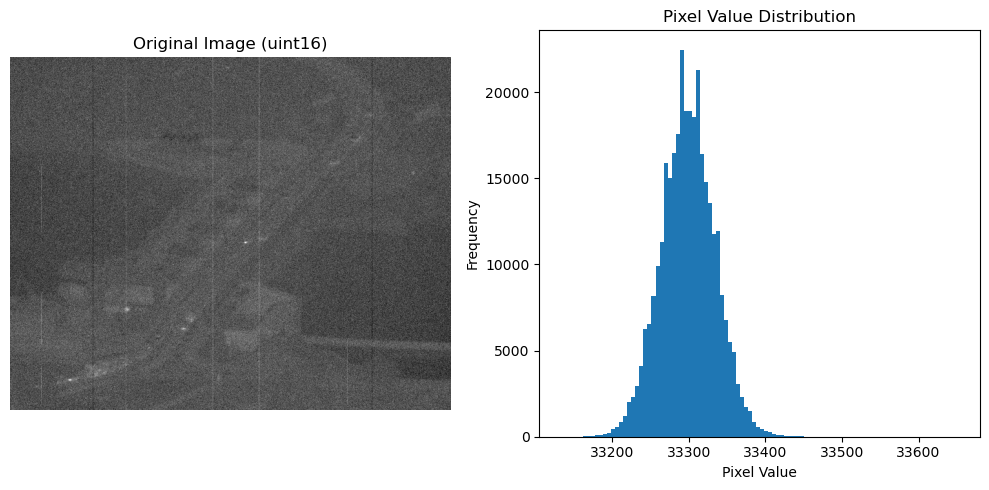

In [27]:
# For visualization, we need to normalize 16-bit to 8-bit
def normalize_for_display(img_16bit):
    """Normalize 16-bit image to 8-bit for display"""
    img_normalized = (img_16bit - np.min(img_16bit)) / (np.max(img_16bit) - np.min(img_16bit))
    img_8bit = (img_normalized * 255).astype(np.uint8)
    return img_8bit

# Display original image (normalized for viewing)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(normalize_for_display(img_gray), cmap='gray')
plt.title(f'Original Image ({img_gray.dtype})')
plt.axis('off')

# Show histogram to understand distribution
plt.subplot(1, 2, 2)
plt.hist(img_gray.flatten(), bins=100, range=(np.min(img_gray), np.max(img_gray)))
plt.title('Pixel Value Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

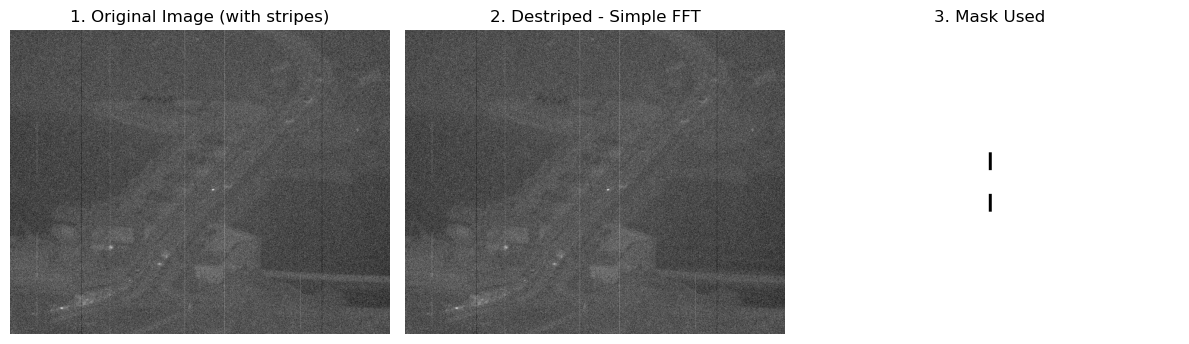

Destriped image dtype: uint16
Destriped range: [33130, 33652]


In [28]:
# Method 1: Simple FFT
destriped_simple, mask1 = destripe_fft_simple(img_gray, stripe_width=1)

# Display results
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalize_for_display(img_gray), cmap='gray')
plt.title('1. Original Image (with stripes)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(normalize_for_display(destriped_simple), cmap='gray')
plt.title('2. Destriped - Simple FFT')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask1, cmap='gray')
plt.title('3. Mask Used')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Destriped image dtype: {destriped_simple.dtype}")
print(f"Destriped range: [{np.min(destriped_simple)}, {np.max(destriped_simple)}]")

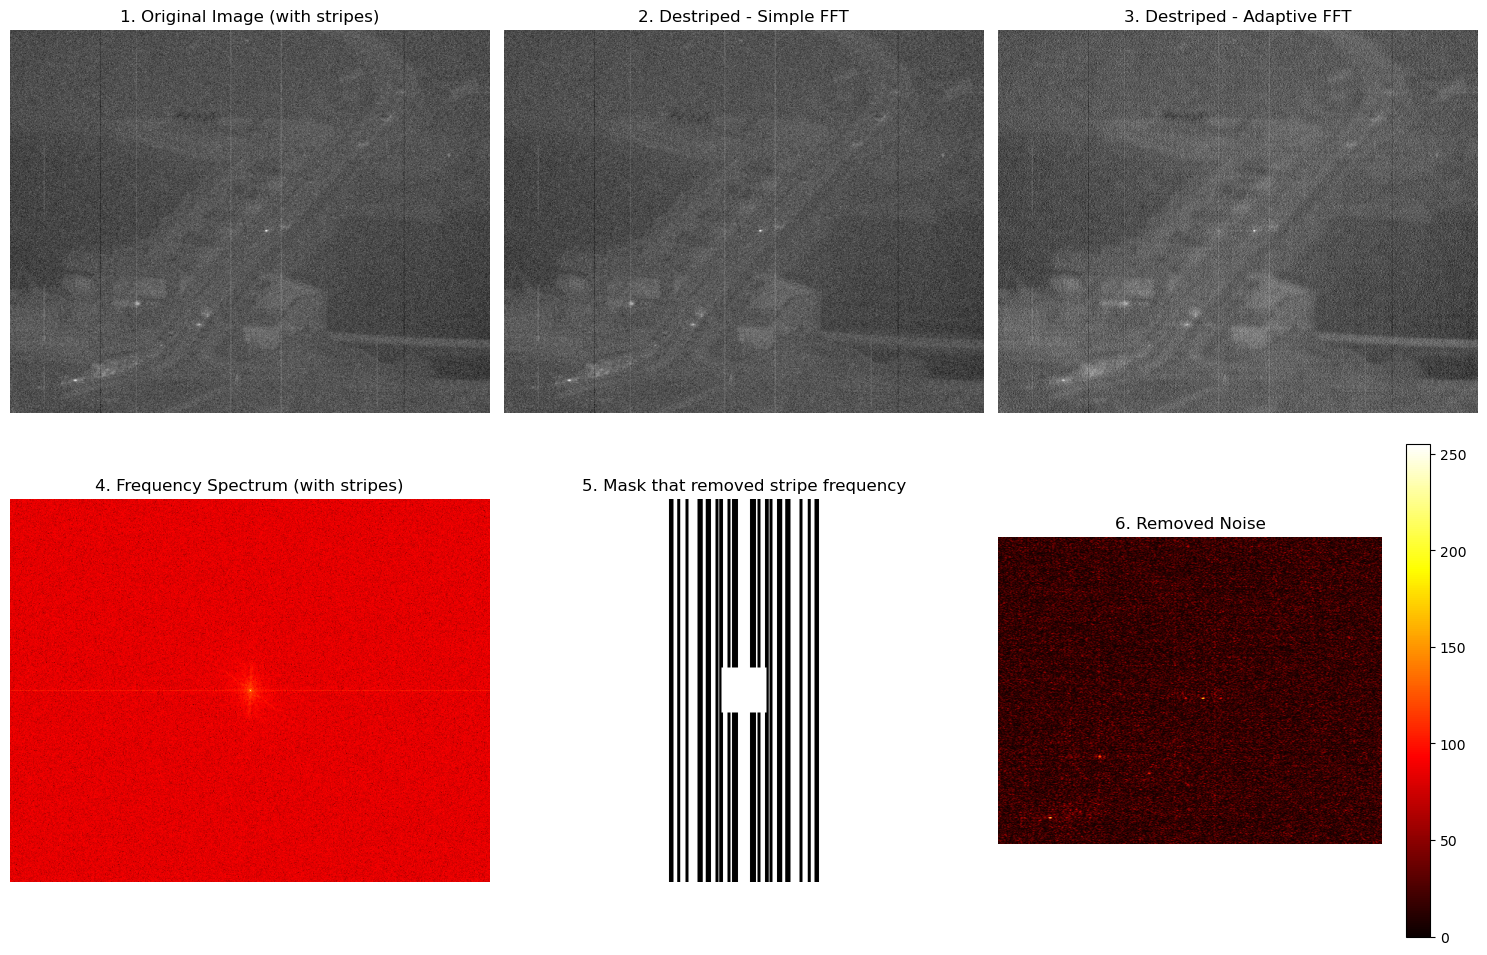

In [34]:
# Method 2: Adaptive FFT
destriped_adaptive, spectrum, mask2 = destripe_adaptive(img_gray)

# Display results
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(normalize_for_display(img_gray), cmap='gray')
plt.title('1. Original Image (with stripes)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(normalize_for_display(destriped_simple), cmap='gray')
plt.title('2. Destriped - Simple FFT')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(normalize_for_display(destriped_adaptive), cmap='gray')
plt.title('3. Destriped - Adaptive FFT')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(spectrum, cmap='hot')
plt.title('4. Frequency Spectrum (with stripes)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask2, cmap='gray')
plt.title('5. Mask that removed stripe frequency')
plt.axis('off')

# Show difference (use same normalization)
diff = cv2.absdiff(img_gray.astype(np.float32), destriped_adaptive.astype(np.float32))
diff_normalized = (diff - np.min(diff)) / (np.max(diff) - np.min(diff)) * 255
plt.subplot(2, 3, 6)
plt.imshow(diff_normalized.astype(np.uint8), cmap='hot')
plt.title('6. Removed Noise')
plt.axis('off')
plt.colorbar()

plt.tight_layout()
plt.show()